In [1]:
import re
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
#from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
%config InlineBackend.figure_format = "retina"

high confidence complexes?

In [3]:
YM = pl.read_csv(data_dir/"Pipeline/21_YM_pae/all_pdb_present_21_YM_pae_pool_pipeline_complexes_combfold_results.csv")
YM_trimmed = pl.read_csv(data_dir/"Pipeline/22_YM_pae_trimmed/all_pdb_present_22_YM_pae_trimmed_pool_pipeline_complexes_combfold_results.csv")

In [4]:
def add_uniprot_count(complexes: pl.DataFrame, col: str = "identifiers") -> pl.DataFrame:
    """Adds n_uniprot_ids: distinct UniProt IDs per row, e.g. 'P32527(0)|P36008(0)' -> 2"""
    assert col in complexes.columns, f"column '{col}' not in DataFrame"
    return complexes.with_columns(
        n_uniprot_ids =
        pl.col(col)
        .str.split("|")
        .list.eval(pl.element().str.replace(r"\(\d+\)$", ""))   # drop the "(n)" stoichiometry
        .list.n_unique()
    )




def add_max_confidence(complex_predictions: pl.DataFrame, output_column: str = "max_confidence") -> pl.DataFrame:
    """Adds the highest value in any CF_*_confidence column ("{0: 78.5, ...}") and which pred it came from."""
    confidence_columns = [c for c in complex_predictions.columns if c.startswith("CF_") and c.endswith("_confidence")]
    assert confidence_columns, "No CF_*_confidence columns found"
    index_to_pred = {i: c.split("_")[1] for i, c in enumerate(confidence_columns)}   # {0: "1", 1: "2", 2: "3", 3: "true"}

    max_per_pred = pl.concat_list(
        pl.col(confidence_columns)
        .str.replace_all(r"\d+:", "")                 # drop the dict keys
        .str.extract_all(r"-?\d+(?:\.\d+)?")
        .list.eval(pl.element().cast(pl.Float64))
        .list.max()
    )
    return complex_predictions.with_columns(
        max_per_pred.list.max().alias(output_column),
        max_per_pred.list.arg_max().replace_strict(index_to_pred).alias("best_pred"),
    )

In [5]:
YM_with_counts = add_uniprot_count(YM)
YM_trimmed_with_counts  = add_uniprot_count(YM_trimmed)
# all of them already have at least 3 prot, so no need to filter

In [6]:
YM_with_counts_cf = add_max_confidence(YM_with_counts)
YM_trimmed_with_counts_cf = add_max_confidence(YM_trimmed_with_counts)


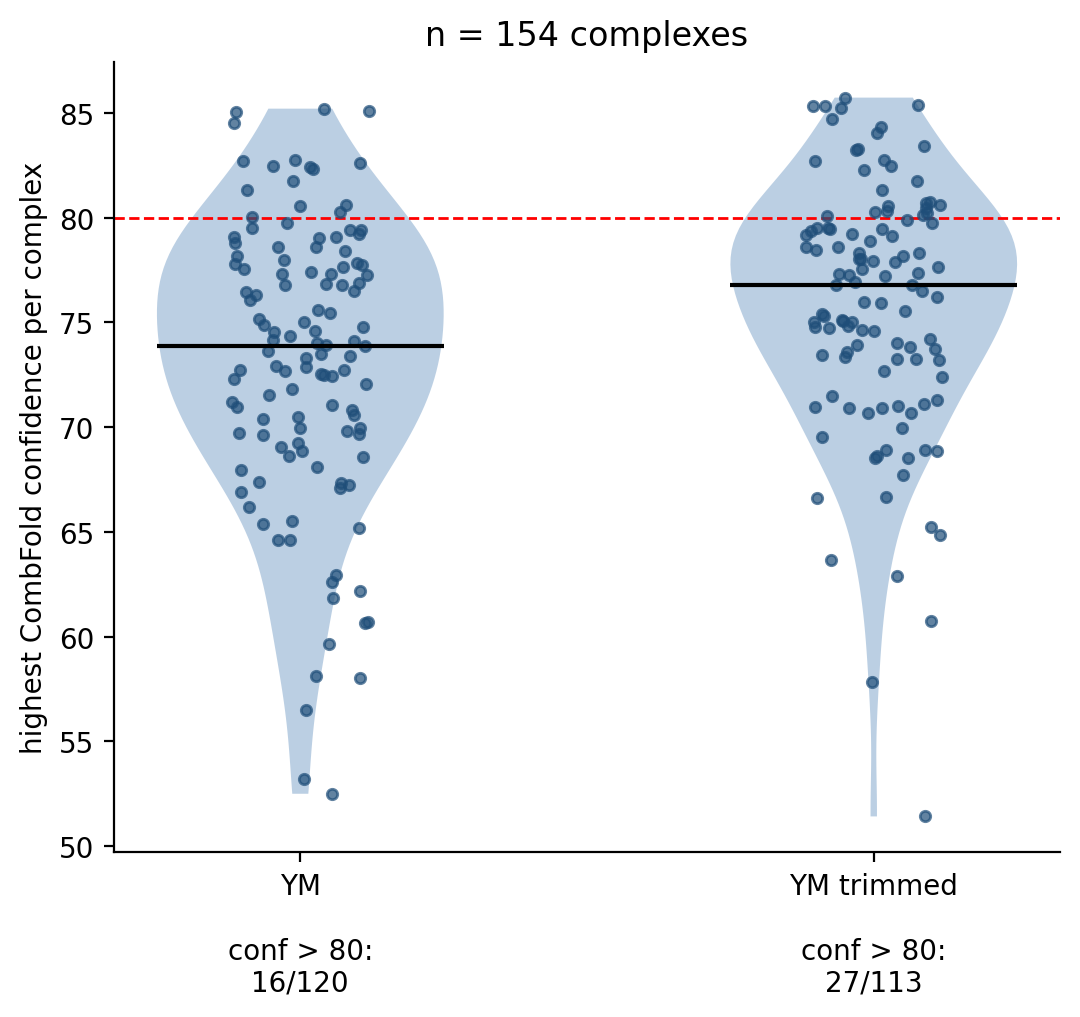

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

CONF_THRESHOLD = 80
run_tables = {                       # violin order: tick label -> dataframe with max_confidence
    "YM": YM_with_counts_cf,
    "YM trimmed": YM_trimmed_with_counts_cf,
}

for run_name, run_table in run_tables.items():
    assert "max_confidence" in run_table.columns, f"{run_name}: run add_max_confidence first"
    assert run_table["complex_ac"].is_unique().all(), f"{run_name}: more than one row per complex"
complex_sets = [set(run_table["complex_ac"]) for run_table in run_tables.values()]
assert all(s == complex_sets[0] for s in complex_sets), "runs contain different complexes"

confidences_per_run = [run_table["max_confidence"].drop_nulls().to_list() for run_table in run_tables.values()]
for run_name, confidences in zip(run_tables, confidences_per_run):
    assert confidences, f"{run_name}: no complex has a confidence value"

rng = np.random.default_rng(0)       # fixed seed -> same dot jitter every time
fig, ax = plt.subplots(figsize=(5.5, 5.2))
violins = ax.violinplot(confidences_per_run, showextrema=False)
for body in violins["bodies"]:
    body.set_facecolor("#8fb0d1")
    body.set_alpha(0.6)
for position, confidences in enumerate(confidences_per_run, start=1):
    ax.scatter(position + rng.uniform(-0.12, 0.12, len(confidences)), confidences,
               s=14, color="#1f4e79", alpha=0.7, zorder=3)
    ax.hlines(np.median(confidences), position - 0.25, position + 0.25, color="black", zorder=4)
ax.axhline(CONF_THRESHOLD, color="red", linestyle="--", linewidth=1, zorder=2)

n_above_threshold = [sum(c > CONF_THRESHOLD for c in confidences) for confidences in confidences_per_run]
ax.set_xticks(range(1, len(run_tables) + 1),
              [f"{run_name}\n\nconf > {CONF_THRESHOLD}:\n{n_above}/{len(confidences)}"
               for run_name, n_above, confidences in zip(run_tables, n_above_threshold, confidences_per_run)])
ax.set_ylabel("highest CombFold confidence per complex")
ax.set_title(f"n = {YM_with_counts_cf.height} complexes")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

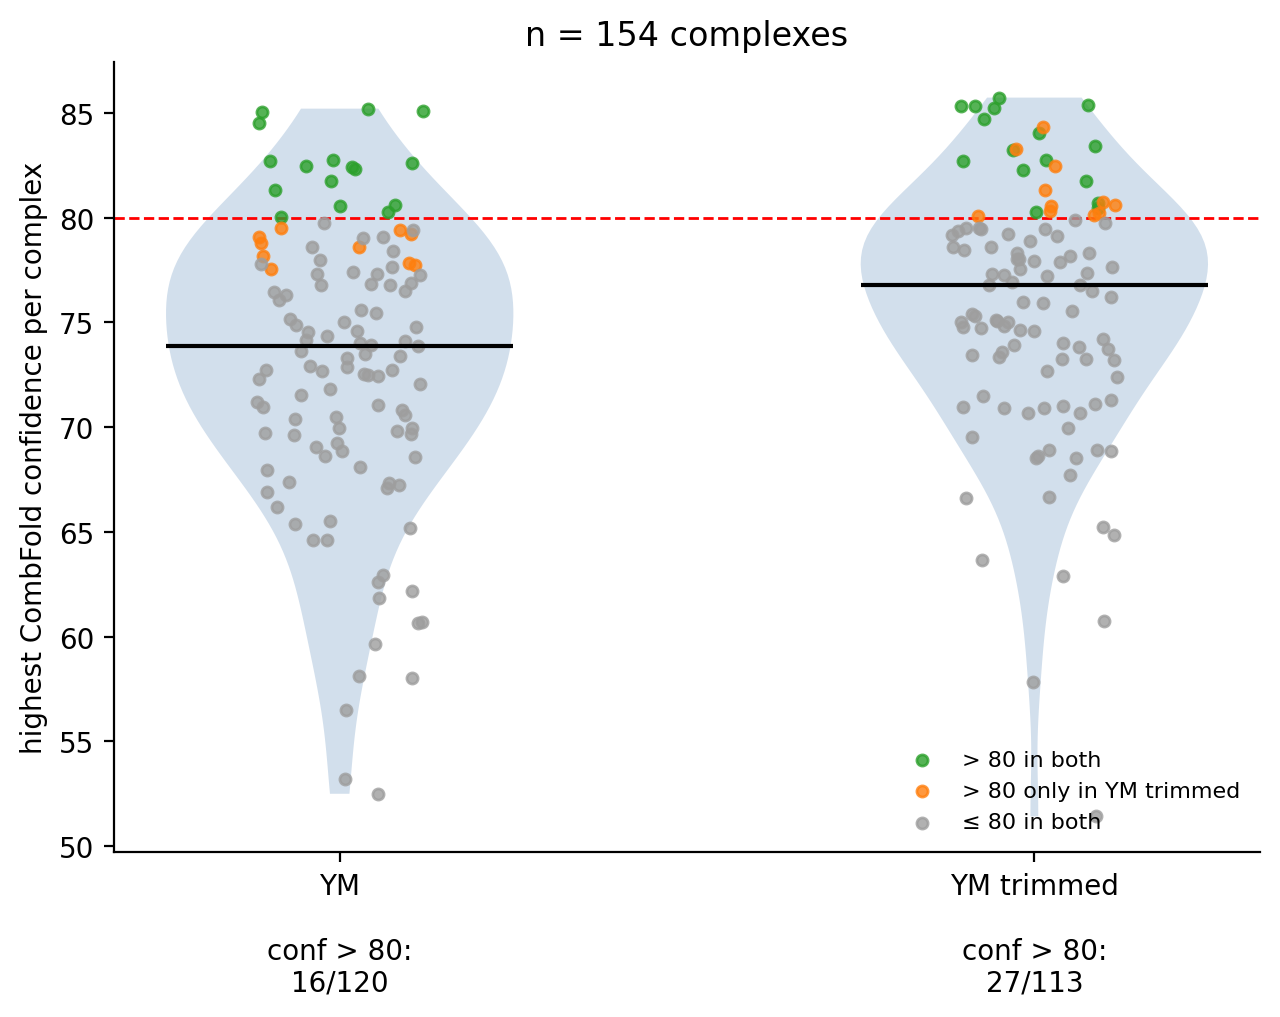

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

CONF_THRESHOLD = 80
run_tables = {                       # violin order: tick label -> dataframe with max_confidence
    "YM": YM_with_counts_cf,
    "YM trimmed": YM_trimmed_with_counts_cf,
}
category_colors = {
    f"> {CONF_THRESHOLD} in both": "#2ca02c",
    f"> {CONF_THRESHOLD} only in YM": "#1f77b4",
    f"> {CONF_THRESHOLD} only in YM trimmed": "#ff7f0e",
    f"≤ {CONF_THRESHOLD} in both": "#9e9e9e",
}

for run_name, run_table in run_tables.items():
    assert "max_confidence" in run_table.columns, f"{run_name}: run add_max_confidence first"
    assert run_table["complex_ac"].is_unique().all(), f"{run_name}: more than one row per complex"
complex_sets = [set(run_table["complex_ac"]) for run_table in run_tables.values()]
assert all(s == complex_sets[0] for s in complex_sets), "runs contain different complexes"

# one row per complex, one confidence column per run, plus its threshold category
above_in_ym = pl.col("YM") > CONF_THRESHOLD
above_in_trimmed = pl.col("YM trimmed") > CONF_THRESHOLD
confidence_by_complex = (
    YM_with_counts_cf.select("complex_ac", pl.col("max_confidence").alias("YM"))
    .join(YM_trimmed_with_counts_cf.select("complex_ac", pl.col("max_confidence").alias("YM trimmed")),
          on="complex_ac", how="inner")
    .with_columns(
        threshold_category=pl.when(above_in_ym & above_in_trimmed).then(pl.lit(f"> {CONF_THRESHOLD} in both"))
        .when(above_in_ym).then(pl.lit(f"> {CONF_THRESHOLD} only in YM"))
        .when(above_in_trimmed).then(pl.lit(f"> {CONF_THRESHOLD} only in YM trimmed"))
        .otherwise(pl.lit(f"≤ {CONF_THRESHOLD} in both"))       # also: no output in one run and ≤ threshold in the other
    )
)

confidences_per_run = [confidence_by_complex[run_name].drop_nulls().to_list() for run_name in run_tables]
for run_name, confidences in zip(run_tables, confidences_per_run):
    assert confidences, f"{run_name}: no complex has a confidence value"

rng = np.random.default_rng(0)       # fixed seed -> same dot jitter every time
fig, ax = plt.subplots(figsize=(6.5, 5.2))
violins = ax.violinplot(confidences_per_run, showextrema=False)
for body in violins["bodies"]:
    body.set_facecolor("#8fb0d1")
    body.set_alpha(0.4)

categories_in_legend = set()
for position, run_name in enumerate(run_tables, start=1):
    run_points = confidence_by_complex.filter(pl.col(run_name).is_not_null())
    jitter = rng.uniform(-0.12, 0.12, run_points.height)
    for category, color in category_colors.items():
        in_category = (run_points["threshold_category"] == category).to_numpy()
        ax.scatter(position + jitter[in_category], run_points[run_name].to_numpy()[in_category],
                   s=16, color=color, alpha=0.8, zorder=3,
                   label=category if category not in categories_in_legend and in_category.any() else None)
        if in_category.any():
            categories_in_legend.add(category)
    ax.hlines(np.median(run_points[run_name]), position - 0.25, position + 0.25, color="black", zorder=4)
ax.axhline(CONF_THRESHOLD, color="red", linestyle="--", linewidth=1, zorder=2)

n_above_threshold = [sum(c > CONF_THRESHOLD for c in confidences) for confidences in confidences_per_run]
ax.set_xticks(range(1, len(run_tables) + 1),
              [f"{run_name}\n\nconf > {CONF_THRESHOLD}:\n{n_above}/{len(confidences)}"
               for run_name, n_above, confidences in zip(run_tables, n_above_threshold, confidences_per_run)])
ax.set_ylabel("highest CombFold confidence per complex")
ax.set_title(f"n = {confidence_by_complex.height} complexes")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

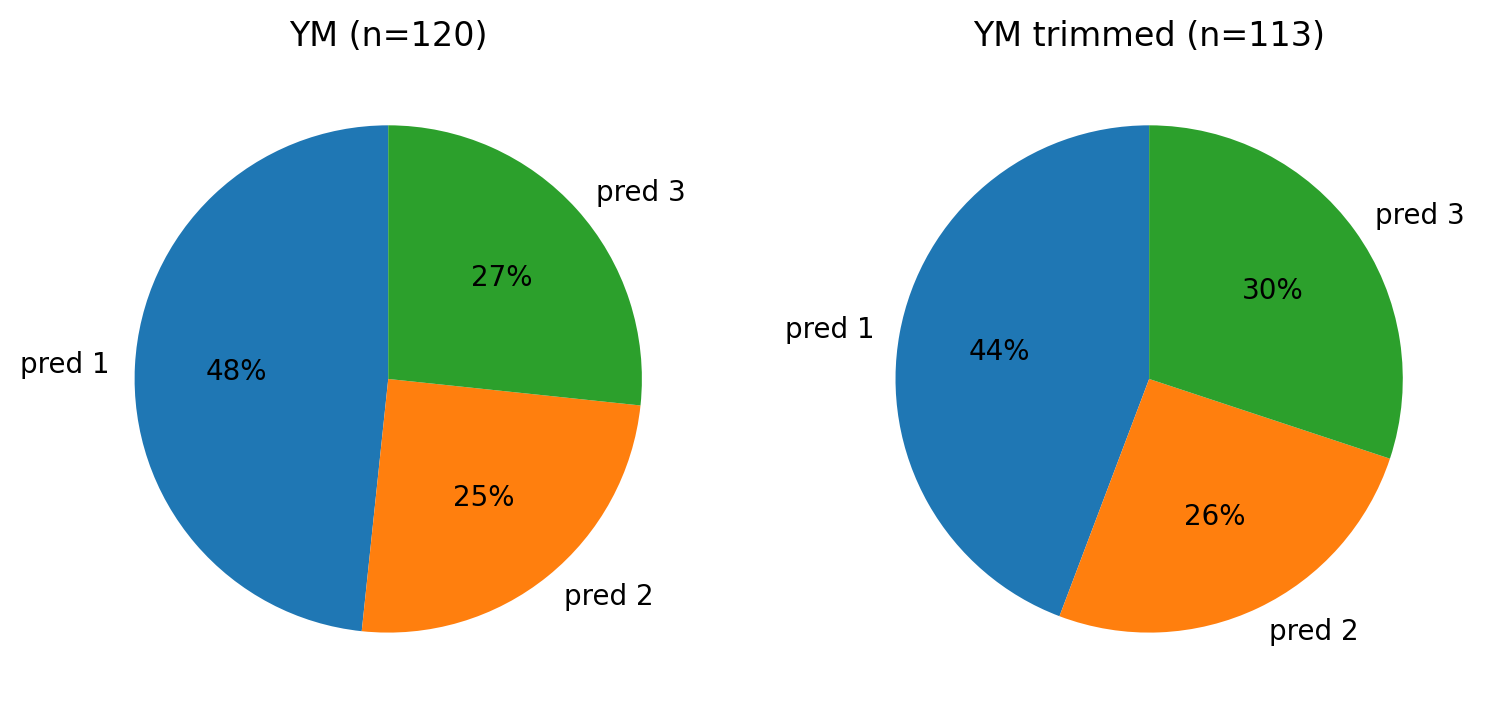

In [13]:
run_tables = {"YM": YM_with_counts_cf, "YM trimmed": YM_trimmed_with_counts_cf}

fig, axes = plt.subplots(1, len(run_tables), figsize=(9, 4.5))
for ax, (run_name, run_table) in zip(axes, run_tables.items()):
    best_pred_counts = run_table["best_pred"].drop_nulls().value_counts().sort("best_pred")
    ax.pie(best_pred_counts["count"], labels=[f"pred {p}" for p in best_pred_counts["best_pred"]],
           autopct="%1.0f%%", startangle=90)
    ax.set_title(f"{run_name} (n={best_pred_counts['count'].sum()})")
plt.show()

## Which complexes have potential

1. Check pdb mapping
2. Go terms

In [ ]:
YM_CO_overlap = pl.read_csv( data_dir/ "Pipeline/12_Yeastmap/input_12_yeastmap.tsv")